In [1]:
!pip install "cvxpy[ECOS]"
import pandas as pd
import numpy as np 
import cvxpy as cp
import gl_reg as glr

In [111]:
#signals_wwd = np.loadtxt("/Users/chrisduran/Desktop/315/wwd_sigs.csv",delimiter = ',',  skiprows=1, usecols = range(1,62))
#signals_wwd = np.loadtxt("/Users/chrisduran/Desktop/315/wwd_sig_iteration2.csv",delimiter = ',',  skiprows=1, usecols = range(1,62))
#signals_wwd = np.loadtxt("/Users/chrisduran/Desktop/315/wwd_sig_iteration3.csv",delimiter = ',',  skiprows=1, usecols = range(1,62))
signals_wwd = np.loadtxt("/Users/chrisduran/Desktop/315/wwd_sig_iteration4.csv",delimiter = ',',  skiprows=1, usecols = range(1,62))
#signals_wwd = np.loadtxt("/Users/chrisduran/Desktop/315/wwd_sig_iteration5.csv",delimiter = ',',  skiprows=1, usecols = range(1,62))

In [3]:
regressor1_wwd = np.loadtxt("/Users/chrisduran/Desktop/315/regressor1_wwd.csv",delimiter = ',',  skiprows=1, usecols = range(1,62))
print(regressor1_wwd.shape) 

(38, 61)


In [4]:
regressor2_wwd = np.loadtxt("/Users/chrisduran/Desktop/315/regressor2_wwd.csv",delimiter = ',',  skiprows=1, usecols = range(1,62))
print(regressor2_wwd.shape) 

(38, 61)


In [5]:
regressor3_wwd = np.loadtxt("/Users/chrisduran/Desktop/315/regressor3_wwd.csv",delimiter = ',',  skiprows=1, usecols = range(1,62))
print(regressor3_wwd.shape) 

(38, 61)


In [112]:
X_REAL_DATA = signals_wwd
X_noisy = signals_wwd.copy() 
r1 = regressor1_wwd
r2 = regressor2_wwd
r3 = regressor3_wwd
r4 = np.ones_like(X_noisy) 


P = [r1, r2, r3, r4]

   ###################################

from sklearn import metrics

def lowertrian(Lap):
                                                ##Extract the lower triangular part of the Laplacian
    N = Lap.shape[0]
    return Lap[np.tril_indices(N, k=-1)]

def vec(S):
    return S.flatten('F') 

def Pbeta(P, b):
    """Construct the signal from regressors and beta"""
    R = sum([P[i] * b[i] for i in range(len(P))])
    return vec(R)

def pstack(P):
    """Stack regressor arrays into one tall matrix"""
    Pvec = [p.ravel(order="F") for p in P]
    return np.stack(Pvec, axis=1)

def prune(L, threshold):
    """Zero out small values in Laplacian"""
    temp = L.copy()
    temp[np.abs(temp) < threshold] = 0
    return temp


In [113]:
def optimize_L(hatS, P, beta, w1, w2):
    """Optimize the Laplacian matrix"""
    N, n = hatS.shape
    L = cp.Variable((N, N), symmetric=True)
    constraints = [
        cp.trace(L) == N,
        L - cp.diag(cp.diag(L)) <= 0,
        cp.diag(L) >= 0,
        L @ np.ones((N, 1)) == 0 ]
    
    x = vec(hatS) - Pbeta(P, beta)
    D = cp.kron(np.identity(n), L)
    
    objective = cp.Minimize(w1 * cp.quad_form(x, D) + w2 * cp.norm(L, 'fro') ** 2)
    cp.Problem(objective, constraints).solve(solver= cp.ECOS, warm_start=True, verbose=False)
   
    return L.value

def optimize_hatS(L, P, beta, S, w1):
    """Optimize the estimated signal"""
    N, n = S.shape
    InXL = np.kron(np.identity(n), L) 
    term1 = w1 * InXL + np.identity(N * n)
    term2 = np.linalg.pinv(term1) 
    term3 = vec(S) + w1 * (InXL @ Pbeta(P, beta))
    return (term2 @ term3).reshape((N, n), order="F") 

    
def optimize_beta(P, L, hatS):
    """Optimize the regression coefficients"""
    n = hatS.shape[1]
    InXL = np.kron(np.identity(n), L)
    Ptemp = pstack(P)
    term1 = Ptemp.T @ InXL @ Ptemp
    term2 = np.linalg.pinv(term1) @ Ptemp.T  
    term3 = InXL @ vec(hatS)
    return term2 @ term3

def GSPRegression(X_noisy, P, w1, w2, max_iter=100, threshhold=0.015):
    """
    Graph signal regression with Laplacian learning.
    Returns: [Learned Laplacian, Estimated Signal, Beta, Untouched Laplacian]
    """
    N, n = X_noisy.shape
    hatS = X_noisy.copy()
    hatS_0 = X_noisy.copy()
    objective = [0] * max_iter
    beta = np.zeros((len(P), 1))
    

    for i in range(max_iter):
        L = optimize_L(hatS, P, beta, w1, w2)
        hatS = optimize_hatS(L, P, beta, X_noisy, w1)
        beta = optimize_beta(P, L, hatS)

        x = vec(hatS) - Pbeta(P, beta)
        D = np.kron(np.identity(n), L)
        arg1 = np.linalg.norm(hatS - hatS_0, 'fro') ** 2
        arg2 = w1 * x.T @ D @ x
        arg3 = w2 * np.linalg.norm(L, 'fro') ** 2
        objective[i] = arg1 + arg2 + arg3

        if i >= 2 and abs(objective[i] - objective[i - 1]) < 1e-4:
            break
    L_pruned = prune(L, threshold=0.015)
    return [prune(L, threshhold), hatS, beta, L]
 


In [114]:
#print("L and L_hat equal?", np.allclose(L, L_hat)) 
#print("Difference Fro norm:", np.linalg.norm(L - L_hat, 'fro'))

In [115]:
def Pbeta(P, beta): 
    #for i, Pi in enumerate(P):
     #   print(f"P[{i}].shape = {Pi.shape}")
    P_stack = np.column_stack([
        np.array(Pi).flatten(order="F") for Pi in P ])
    beta = beta.flatten()
    #print("P_stack.shape:", P_stack.shape)
    #print("beta.shape:", beta.shape)
    return P_stack @ beta 

w1 = 0.0009  # smoothness penalty
w2 = 1.15  # sparsity penalty

L_hat, S_hat, beta_hat, raw_L = GSPRegression(X_noisy, P, w1, w2)

In [116]:
L = GSPRegression(X_noisy,P, w1,w2 )[0] 

In [128]:
#np.save('L.npy', L) 
#L = np.load('L.npy') ##recall saved L run 

In [50]:
D = np.loadtxt("/Users/chrisduran/Desktop/315/wwd_locations.csv",delimiter = ',',  skiprows=1, usecols = range(1,38))

In [122]:
Lprime = np.full(D.shape, 999)  # default to 999
Lprime[(D < 25000) & (D > 0)] = -1
Lprime[D > 70000] = 0
#print(Lprime) 

[[999 999 999 ...  -1  -1   0]
 [999 999 999 ... 999  -1 999]
 [999 999 999 ...   0 999 999]
 ...
 [ -1  -1 999 ... 999 999   0]
 [  0 999 999 ...   0   0 999]
 [999 999  -1 ...   0 999 999]]


In [118]:
## Distance Matrix (Mod. in R, threshold in meters, compare)
threshold_meters = 190_000
adj_D = (D[:, 1:] < threshold_meters).astype(int)
#adj_D = adj_D_df.to_numpy()  
np.fill_diagonal(adj_D, 0)


adj_L = np.abs(L_hat.copy())
np.fill_diagonal(adj_L, 0)

In [119]:
degrees = np.sum(adj_D, axis=1)
D_mat = np.diag(degrees)

#Normalized 
L_norm = (L_hat.shape[0] / np.trace(raw_L)) * raw_L

In [54]:
import networkx as nx
import eval_metrics as met
import matplotlib.pyplot as plt

In [ ]:
Lprime = np.full(D.shape, 999)  # default to 999
Lprime[(D < 25000) & (D > 0)] = -1
Lprime[D > 70000] = 0

degrees = np.sum(adj_D, axis=1)
D_mat = np.diag(degrees)

#Normalized 
L_norm = (L_hat.shape[0] / np.trace(raw_L)) * raw_L
L_est_BA = L_hat.copy()

L_prBA = prune(L_est_BA, 0.02)
adj_BA = np.abs(L_prBA) - np.diag(np.diag(L_prBA))
G_est_BA = nx.from_numpy_array(adj_BA)

pos = nx.circular_layout(G_est_BA)
nx.draw(G_est_BA, pos, node_size=275, with_labels=False)

labels = {i: str(i) for i in G_est_BA.nodes()}


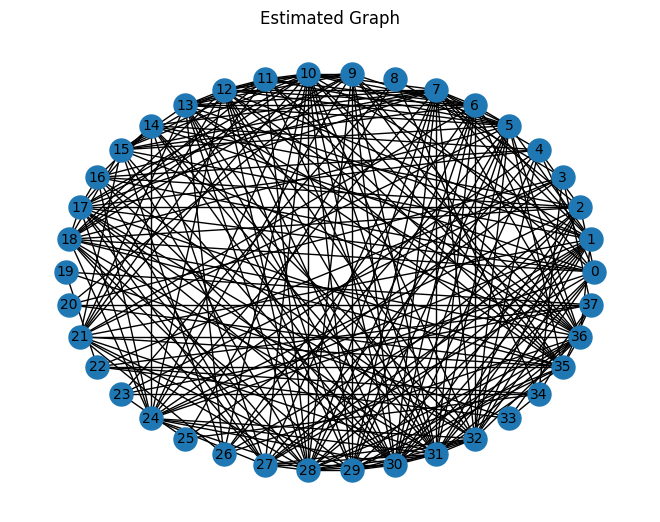

In [121]:
L_est_BA = L_hat.copy()

L_prBA = prune(L_est_BA, 0.02)
adj_BA = np.abs(L_prBA) - np.diag(np.diag(L_prBA))
G_est_BA = nx.from_numpy_array(adj_BA)

pos = nx.circular_layout(G_est_BA)
nx.draw(G_est_BA, pos, node_size=275, with_labels=False)

labels = {i: str(i) for i in G_est_BA.nodes()}
nx.draw_networkx_labels(G_est_BA, pos, labels, font_size=10)

plt.title("Estimated Graph")
#plt.savefig('Node_Connections_WWD.png', bbox_inches='tight')
plt.show()

In [89]:
i_indices, j_indices = np.where(L_hat > 0)
positive_entries = [(i, j, L_hat[i, j]) for i, j in zip(i_indices, j_indices)]

In [40]:
!pip install seaborn
import seaborn as sns
import matplotlib.pyplot as plt

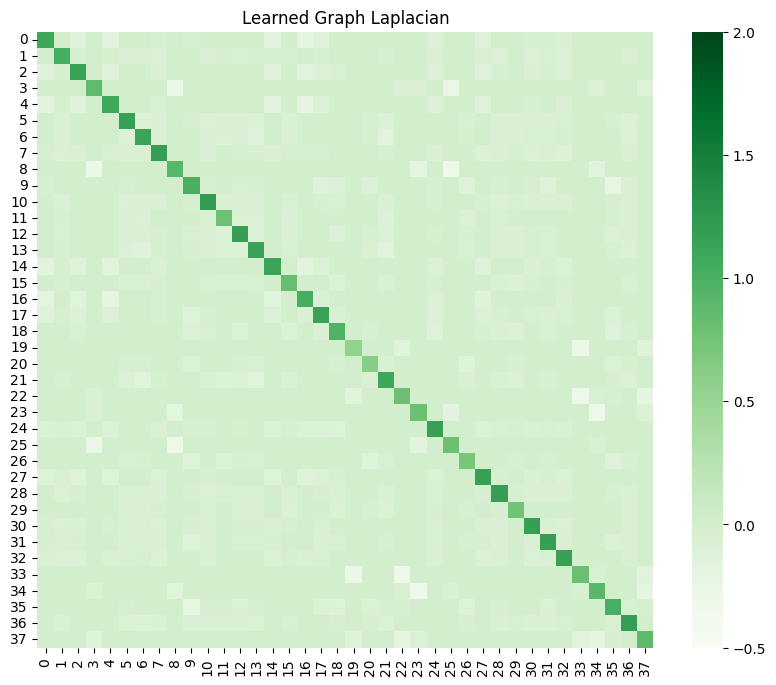

In [22]:
plt.figure(figsize=(10, 8))
sns.heatmap(L_prBA, cmap="Greens", vmin=-0.5, vmax=2, square=True)
plt.title("Learned Graph Laplacian")
#plt.savefig('Node_HMap_WWD.png', bbox_inches='tight')
plt.show()

In [104]:
def findHParams(X_noisy,              # The Observed Signal
                P,                   # The Observed Regressors
                L,               # The partial ground truth laplacian
                x_max = 0.001,            # center x coord of mesh
                y_max = 0.5,            # center y coord of mesh
                epsilon = .1,         # Distance from midpoint to edge of the mesh
                steps = 3,            # Number of recursive steps
                maxiter = 3,          # Max number of iterations GL_Reg will perform to learn a laplacian
                threshold = 10**(-3), # Threshold for pruning insignificant edges
                digits = 4,           # How many decimals to keep in coordinates/metric
                verbose = False):     # Set True to see the path grid search takes 
    # Initializations
    bestResult = glr.GSPRegression(X_noisy, P, x_max,y_max, maxiter, threshold)
    #print(f"bestResult:\n  Result:\n{bestResult[0]}\n  L(estimated):\n{bestResult[3]}\n\n") # TESTING
    maxMeasure = round(met.metricsprf(L, bestResult[0])[2], digits)
    print(f"maxMeasure:\n{maxMeasure}") # TESTING
    if verbose: print("Initial F-Measure is " + str(maxMeasure))
    
    # Create the first 
    X = [.01] + [round(x, digits) for x in np.linspace(x_max - epsilon, x_max + epsilon, 4) if x > 0]
    Y = [.01] + [round(y, digits) for y in np.linspace(y_max - epsilon, y_max + epsilon, 4) if y > 0]
    for i in range(steps):
        for x in X:
            for y in Y:
                curRes = glr.GSPRegression(X_noisy, P, x,y, maxiter, threshold)
                curL = curRes[0]
                curMeasure = round(met.metricsprf(L, curL)[2], digits)
                if verbose: print("Current F-Measure is " + str(curMeasure) + " for x = " + str(x) + " y = " + str(y))
                if curMeasure > maxMeasure:
                    x_max = x
                    y_max = y 
                    bestResult = curRes
                    maxMeasure = curMeasure
                    if verbose: print("New max of " + str(maxMeasure) + " at (" + str(x_max) + ", " + str(y_max) +")")
        if verbose: print("Step " + str(i+1) + " completed.")
        X = [round(i, digits) for i in np.linspace(x_max - epsilon*(.1), x_max + epsilon*(.1), 4) if i > 0]  
        Y = [round(j, digits) for j in np.linspace(y_max - epsilon*(.1), y_max + epsilon*(.1), 4) if j > 0]
    return([x_max, y_max] + bestResult)

results = findHParams(X_noisy, P, L)

#print(results[1])


maxMeasure:
0.8371


In [23]:
#print(results)

In [62]:
def findHParams(X_noisy,              # The Observed Signal
                P0,                   # The Observed Regressors
                Lprime,               # The partial ground truth laplacian
                x_max = 1,            # center x coord of mesh
                y_max = 1,            # center y coord of mesh
                epsilon_1 = 1/2,         # Distance from midpoint to edge of the mesh
                epsilon_2 = 1/2, 
                q_1 = 0.001, 
                q_2 = 0.002, 
                steps = 3,            # Number of recursive steps
                maxiter = 3,          # Max number of iterations GL_Reg will perform to learn a laplacian
                threshold = 10**(-3), # Threshold for pruning insignificant edges
                digits = 4,           # How many decimals to keep in coordinates/metric
                verbose = False):     # Set True to see the path grid search takes 
    # Initializations
    bestResult = glr.GSPRegression(X_noisy, P0, x_max,y_max, maxiter, threshold)
    # print(f"bestResult:\n  Result:\n{bestResult[0]}\n  L(estimated):\n{bestResult[3]}\n\n") # TESTING
    maxMeasure = round(met.metricsprf(Lprime, bestResult[0])[2], digits)
    # print(f"maxMeasure:\n{maxMeasure}") # TESTING
    if verbose: print("Initial F-Measure is " + str(maxMeasure))
    
    # Create the first 
    X = [q_1] + [round(x, digits) for x in np.linspace(x_max - epsilon_1, x_max + epsilon_1, 4) if x > 0]
    Y = [q_2] + [round(y, digits) for y in np.linspace(y_max - epsilon_2, y_max + epsilon_2, 4) if y > 0]
    for i in range(steps):
        for x in X:
            for y in Y:
                curRes = glr.GSPRegression(X_noisy, P0, x,y, maxiter, threshold)
                curL = curRes[0]
                curMeasure = round(met.metricsprf(Lprime, curL)[2], digits)
                if verbose: print("Current F-Measure is " + str(curMeasure) + " for x = " + str(x) + " y = " + str(y))
                if curMeasure > maxMeasure:
                    x_max = x
                    y_max = y 
                    bestResult = curRes
                    maxMeasure = curMeasure
                    if verbose: print("New max of " + str(maxMeasure) + " at (" + str(x_max) + ", " + str(y_max) +")")
        if verbose: print("Step " + str(i+1) + " completed.")
        X = [round(i, digits) for i in np.linspace(x_max - epsilon_1*(.1), x_max + epsilon_1*(.1), 4) if i > 0]  
        Y = [round(j, digits) for j in np.linspace(y_max - epsilon_2*(.1), y_max + epsilon_2*(.1), 4) if j > 0]
    print("-----------------------------------------")
    print("                 Result                  ")
    print("-----------------------------------------")
    print("F-Measure = " + str(maxMeasure) + " at (" + str(x_max) + ", " + str(y_max) + ")")

    return([x_max, y_max] + bestResult)

In [61]:
Results = findHParams(signals_wwd, P, Lprime, x_max= 0.01, y_max=1.9, epsilon_1 = 0.005,epsilon_2 = 0.9) 

KeyboardInterrupt: 

In [105]:
from sklearn import metrics
import numpy as np

# Extract the lower triangular part of a matrix (excluding diagonal)
def lowertrian(Lap):
    N = Lap.shape[0]
    return Lap[np.tril_indices(N, k=-1)]


# Return list of ordered pairs (x, y) where matrix value != given value
def getAddressesMatrix(Mx, val):
    Addr = []
    for x in range(len(Mx)):
        for y in range(len(Mx[x])):
            if Mx[x][y] != val:
                Addr.append((x, y))
    return Addr


# Return value at a list of addresses from a matrix
def getAddrVal(Mx, Addr):
    vals = []
    for i in range(len(Addr)):
        x = Addr[i][0]
        y = Addr[i][1]
        vals.append(Mx[x][y])
    return vals


# Return list of indices where vector values != val
def getAddressesVector(V, val):
    Addr = []
    for i in range(len(V)):
        if V[i] != val:
            Addr.append(i)
    return Addr



In [106]:
def lowertrian(Lap):
    """Extract lower triangular part (excluding diagonal) from a matrix."""
    N = Lap.shape[0]
    return Lap[np.tril_indices(N, k=-1)]

def metricsprf(Lprime, L):

    Lprime_tmp = lowertrian(Lprime)
    L_tmp = lowertrian(L)

    known_indices = [i for i, val in enumerate(Lprime_tmp) if val != 999]

    if len(known_indices) == 0:
        print("No known entries in ground truth Laplacian.")
        return (-1, -1, -1, -1, -1)
    
    # Extract known values
    Lprime_known = Lprime_tmp[known_indices]
    L_known = L_tmp[known_indices]

    # Convert to binary edge indicators
    true_edges = Lprime_known != 0
    learned_edges = L_known != 0

    if np.sum(learned_edges) == 0:
        return (-1, -1, -1, -1, -1)

    
    precision = metrics.precision_score(true_edges, learned_edges)
    recall = metrics.recall_score(true_edges, learned_edges)
    f1 = metrics.f1_score(true_edges, learned_edges)
    nmi = metrics.normalized_mutual_info_score(true_edges, learned_edges)
    accuracy = metrics.accuracy_score(true_edges, learned_edges)
    
    return precision, recall, f1, nmi, accuracy

def getLhatprime(Lhat_in, Lprime_in):
    
    Lhatprime = Lhat_in.copy()
    for i in range(Lhat_in.shape[0]):
        for j in range(Lhat_in.shape[1]):
            if Lprime_in[i, j] != 999:
                Lhatprime[i, j] = Lprime_in[i, j]
    return Lhatprime


In [107]:
def lowertrian(Lap):

    N = Lap.shape[0]
    return Lap[np.tril_indices(N, k=-1)]

def metricsprf(L, L_hat):

    # Remove diagonal and take lower triangle
    L0_lower = lowertrian(L)
    L_lower = lowertrian(L_hat)

    edges_groundtruth = L0_lower != 0
    edges_learned = L_lower != 0

    # If no edges learned, return invalid scores
    if np.sum(edges_learned) == 0:
        return -1, -1, -1, -1

    # Compute metrics
    precision = metrics.precision_score(edges_groundtruth, edges_learned)
    recall = metrics.recall_score(edges_groundtruth, edges_learned)
    f1 = metrics.f1_score(edges_groundtruth, edges_learned)
    nmi = metrics.normalized_mutual_info_score(edges_groundtruth, edges_learned)

    return precision, recall, f1, nmi


In [108]:
precision, recall, f1, nmi = metricsprf(L, Lprime)
print(precision, recall, f1, nmi)  

0.38803088803088803 0.7821011673151751 0.5187096774193548 0.00502981139606612


In [62]:
L_real = L  # real Laplacian matrix (numpy array)
rho = 0.6    

# Get lower triangle of matrix
def toLowerTriangularM(L_real):
    print(L_real[1:5])
    LTM = []
    for i in range(1, L_real.shape[0]):
        row = []
        for j in range(i):
            row.append(L_real[i][j])
        LTM.append(row)
    print(LTM[1:5])
    return LTM 

#LTM = toLowerTriangularM(L_real) ## calling the func. 

In [63]:
# Flatten lower triangle into vector
def listlistTOvector(LTM):
    V = []
    for row in LTM:
        V.extend(row)
    return V

# Reshape vector back into lower triangle list of lists
def LTVectorTOlistlist(V):
    List = []
    row = []
    count = 1
    for val in V:
        row.append(val)
        if len(row) == count:
            List.append(row.copy())
            row.clear()
            count += 1
    return List

    
N = L_prBA.shape[0]
print('N = ', N) # num of nodes in sample 
k = int(N * (N - 1) / 2) 
print('k = ', k) # # total number of locations in lower diagonal matrix of L
s_k = round(k * rho) 
print('s_k = ', s_k) #number of values to copy from complete L to partially known L (L', Lprime)
 
# Randomly mask unknown values in lower triangle with 999
def LprimeLT_from_Llt(L_real, k, s_k):
    LltV = listlistTOvector(L_real)
    j = k - s_k  # number of unknowns

    random.seed(12345)
    for i in range(j):
        while True:
            rand_index = random.randint(0, len(LltV) - 1)
            if LltV[rand_index] != 999:
                LltV[rand_index] = 999
                break
    return LTVectorTOlistlist(LltV)

# Build symmetric Lprime with 999 placeholders
def Lprime_from_LprimeLT(L, LprimeLT):
    Lprime = np.full_like(L, 999, dtype=float)
    N = L.shape[0]

    for i in range(N - 1):
        for j in range(len(LprimeLT[i])):
            if LprimeLT[i][j] != 999:
                Lprime[i + 1][j] = LprimeLT[i][j]
                Lprime[j][i + 1] = LprimeLT[i][j]

    # Diagonal reconstruction
    for i in range(N):
        row_sum = 0
        valid = True
        for j in range(N):
            if i != j:
                if Lprime[i][j] == 999:
                    valid = False
                    break
                row_sum += Lprime[i][j]
        if valid:
            Lprime[i][i] = row_sum

    return Lprime

# Convert full matrix to lower triangle list-of-lists
def toLowerTriangularM(L):
    N = L.shape[0]
    Llt = []
    for i in range(1, N):
        row = []
        for j in range(i):
            row.append(L[i][j])
        Llt.append(row)
    return Llt

# MAIN: Generate Lprime from full L using a known percentage
def getLprime(L, rho):
    N = L.shape[0]
    k = int(N * (N - 1) / 2)
    s_k = round(k * rho)

    Llt = toLowerTriangularM(L)
    LprimeLT = LprimeLT_from_Llt(Llt, k, s_k)
    return Lprime_from_LprimeLT(L, LprimeLT)


N =  38
k =  703
s_k =  422


In [ ]:
def GL_RP(Signals, Regressors, Result, Lprime, normL_true):
    Lhat = glr.GSPRegression(Signals, Regressors, Result[0], Result[1])[0]
    Lhat_prime = glr.getLhatprime(Lhat, Lprime)
    glr.metricsprf(normL_true, Lhat_prime)


In [37]:
#print(getLprime(L_real, 2))

[[-1.70559462  0.         -0.22496769 ...  0.          0.
   0.        ]
 [ 0.          0.          0.         ...  0.          0.
   0.        ]
 [-0.22496769  0.         -2.05672333 ...  0.          0.
   0.        ]
 ...
 [ 0.          0.          0.         ... -0.77883125  0.
   0.        ]
 [ 0.          0.          0.         ...  0.         -2.0257864
   0.        ]
 [ 0.          0.          0.         ...  0.          0.
   0.        ]]


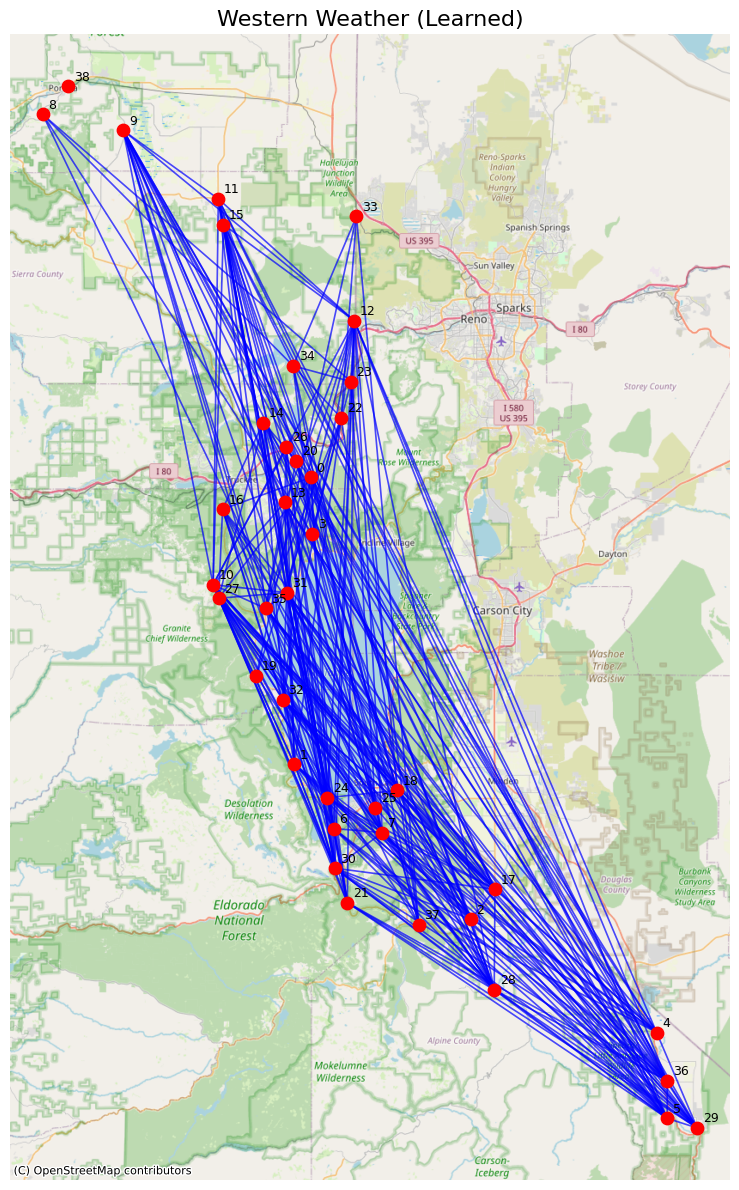

In [139]:
import geopandas as gpd
import contextily as ctx
from shapely.geometry import LineString

# Load station location data
Nlocations = pd.read_csv("/Users/chrisduran/Desktop/315/wwd_ll.csv")

# Create GeoDataFrame from lat/lon
gdf = gpd.GeoDataFrame(
    Nlocations,
    geometry=gpd.points_from_xy(Nlocations["Longitude"], Nlocations["Latitude"]),
    crs="EPSG:4326"
)

# Create learned graph from Laplacian
adj_BA = np.abs(L_prBA) - np.diag(np.diag(L_prBA))
G_est_BA = nx.from_numpy_array(adj_BA)

# Create list of edges from learned graph
edges = []
for i, j in G_est_BA.edges():
    point_i = gdf.loc[i, 'geometry']
    point_j = gdf.loc[j, 'geometry']
    line = LineString([point_i, point_j])
    edges.append(line)

# Convert to GeoDataFrames and project to Web Mercator
edges_gdf = gpd.GeoDataFrame(geometry=edges, crs="EPSG:4326").to_crs(epsg=3857)
gdf = gdf.to_crs(epsg=3857)

# Label nodes with index
for idx, row in gdf.iterrows():
    ax.text(row.geometry.x + 1000, row.geometry.y + 1000, str(idx), fontsize=9, color='black', zorder=3)

# Plot
fig, ax = plt.subplots(figsize=(12, 12))

# Draw edges (learned connections)
edges_gdf.plot(ax=ax, color='blue', linewidth=1.2, alpha=0.7, zorder=1)

# Draw nodes (stations)
gdf.plot(ax=ax, color='red', markersize=80, zorder=2)

# Label nodes with index
for idx, row in gdf.iterrows():
    ax.text(row.geometry.x + 1000, row.geometry.y + 1000, str(idx), fontsize=9, color='black', zorder=3)

# Add basemap
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik, crs=gdf.crs, zoom=10)

# Final plot tweaks
ax.set_axis_off()
ax.set_title("Western Weather (Learned)", fontsize=16)
plt.tight_layout()
plt.savefig("learned_wwd_graph.png", dpi=300)
plt.show()

In [140]:
#5 imputations
precision = np.array([0.3977, 0.3803, 0.3822, 0.3881, 0.3881])
recall    = np.array([0.7687, 0.7976, 0.7586, 0.7643, 0.7821])
f1        = np.array([0.5242, 0.515, 0.5083, 0.5148, 0.5187])

#variances from bootstrapping within each imputation
precision_var = np.array([0.0005, 0.0006, 0.0004, 0.0005, 0.0005])
recall_var    = np.array([0.0004, 0.0003, 0.0004, 0.0003, 0.0003])
f1_var        = np.array([0.0004, 0.0005, 0.0003, 0.0004, 0.0004])

def rubins_rules(Q, U):
    M = len(Q)
    Q_bar = np.mean(Q)
    U_bar = np.mean(U)
    B = np.var(Q, ddof=1)
    T = U_bar + (1 + 1/M) * B
    SE_pooled = np.sqrt(T)
    return Q_bar, SE_pooled

metrics = {
    "Precision": (precision, precision_var),
    "Recall":    (recall, recall_var),
    "F1":        (f1, f1_var)
}

for name, (vals, vars_) in metrics.items():
    pooled, se = rubins_rules(vals, vars_)
    print(f"{name}: {pooled:.3f} ± {se:.3f}")

Precision: 0.387 ± 0.024
Recall: 0.774 ± 0.025
F1: 0.516 ± 0.021


In [143]:
rest = np.mean(recall)
print(rest)

0.77426
